# Análise de Dados: Câncer de Mama de Wisconsin

Este projeto tem como objetivo construir um pipeline completo de análise e modelagem preditiva para o diagnóstico de câncer de mama utilizando o clássico dataset "Wisconsin Breast Cancer" da UCI. O foco está em demonstrar domínio em exploração de dados (EDA), seleção de variáveis, tratamento de multicolinearidade e avaliação de modelos de regressão logística para classificação binária de tumores (benigno vs. maligno).

O projeto prioriza explicações e decisões técnicas, com ênfase em clareza e justificativas em cada etapa — além de servir como evidência de conhecimento prático em Data Science aplicado à saúde.

## 1. BIBLIOTECAS:

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score


## 2. DATASET:

In [18]:
# IMPORTAR O DATASET:
from sklearn.datasets import load_breast_cancer

# CARREGAR O DATASET:
dados = load_breast_cancer()

# TRANSFORMANDO EM UM DATAFRAME:
df = pd.DataFrame(data=dados.data, columns=dados.feature_names)

In [19]:
# ADICIONAR A COLUNA ALVO 'TARGET' AO DATAFRAME
# VALORES: 0 = BENIGNO, 1 = MALIGNO
df['target'] = dados.target

In [20]:
# 5 PRIMEIRAS LINHAS DO DATAFRAME:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [21]:
# INFORMAÇÕES BÁSICAS DO DATASET:
print("📊 INFORMAÇÕES BÁSICAS DO DATASET")
print("="*50)

print(f"\n Shape do dataset: {df.shape}")
print(f"   • {df.shape[0]} registros")
print(f"   • {df.shape[1]} colunas")

print(f"\n Tipos de dados:")
print(df.dtypes)

print(f"\n Informações gerais:")
print(df.info())

print(f"\n Estatísticas descritivas:")
print(df.describe())

print(f"\n Valores nulos por coluna:")
print(df.isnull().sum())

📊 INFORMAÇÕES BÁSICAS DO DATASET

 Shape do dataset: (569, 31)
   • 569 registros
   • 31 colunas

 Tipos de dados:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst com

## 3. ANÁLISE EXPLORATÓRIA DE DADOS (EDA):

### 3.1. DESCRIBE:

In [22]:
# MEDIDAS DESCRITIVAS:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### 3.2. DISTRIBUIÇÃO DO TARGET:

In [28]:
# DISTRIBUIÇÃO DO TARGET:
df['target'].value_counts()  # 0 = Benigno, 1 = Maligno

target
1    357
0    212
Name: count, dtype: int64

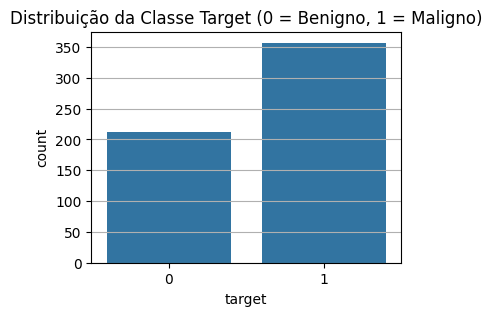

In [ ]:
# PLOTAR A DISTRIBUIÇÃO DA CLASSE ALVO:
plt.figure(figsize=(4, 3))
plt.grid(True)
sns.countplot(x='target', data=df)
plt.title('Distribuição da Classe Target (0 = Benigno, 1 = Maligno)')
plt.show()

### 3.3. MATRIZ DE CORRELAÇÃO:

In [ ]:
# CALCULAR A MATRIZ DE CORRELAÇÃO DE TODAS AS FEATURES COM A VARIÁVEL TARGET
correlations = df.corr()['target'].sort_values(ascending=False)

# EXIBIR AS FEATURES MAIS CORRELACIONADAS COM TARGET
print("LISTA DAS FEATURES MAIS CORRELACIONADAS COM A VARIÁVEL TARGET (DO MAIOR POSITIVO AO NEGATIVO):\n")
print(correlations)

In [39]:
# CALCULAR A CORRELAÇÃO DE TODAS AS FEATURES COM O TARGET
correlations = df.corr()['target']

# EXIBIR AS FEATURES COM CORRELAÇÃO ABSOLUTA MAIOR DO QUE 0.6 (POSITIVA OU NEGATIVA)
print("FEATURES COM |CORRELAÇÃO| >= 0.6 COM O TARGET:")
high_corr_features = correlations[correlations.abs() >= 0.6].index.tolist()
high_corr_features.remove('target')
high_corr_features

FEATURES COM |CORRELAÇÃO| >= 0.6 COM O TARGET:


['mean radius',
 'mean perimeter',
 'mean area',
 'mean concavity',
 'mean concave points',
 'worst radius',
 'worst perimeter',
 'worst area',
 'worst concavity',
 'worst concave points']

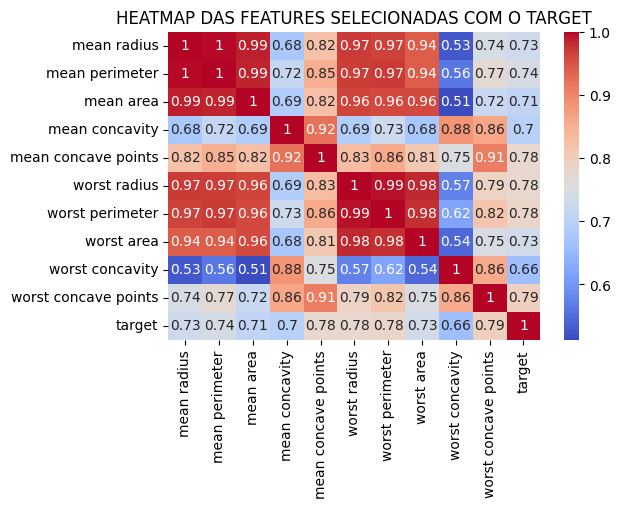

In [44]:
# SELECIONAR APENAS AS FEATURES COM MAIOR CORRELAÇÃO
selected_df = df[high_corr_features + ['target']]

# MATRIZ DE CORRELAÇÃO ENTRE AS FEATURES SELECIONADAS
corr_matrix = selected_df.corr().abs()

# PLOTAR HEATMAP DAS FEATURES SELECIONADAS
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.title('HEATMAP DAS FEATURES SELECIONADAS COM O TARGET')
plt.show()

In [45]:
# ANÁLISE DA MULTICOLINEARIDADE ENTRE AS FEATURES SELECIONADAS:

# DEFINIR LIMIAR ALTO DE CORRELAÇÃO PARA REDUNDÂNCIA
threshold = 0.8

# OBTER MATRIZ DE CORRELAÇÃO DAS FEATURES SELECIONADAS
corr_matrix = selected_df.corr().abs()

# CRIAR UM SET PARA ARMAZENAR FEATURES PARA REMOVER
to_drop = set()

# IDENTIFICAR FEATURES COM ALTA CORRELAÇÃO
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            to_drop.add(colname)

print(f"FEATURES SUGERIDAS PARA REMOVER DEVIDO À ALTA CORRELAÇÃO (> {threshold}):\n", to_drop)

# CRIAR NOVO DATAFRAME COM FEATURES REMANESCENTES
reduced_df = selected_df.drop(columns=to_drop)
print(f"\nFEATURES MANTIDAS APÓS A REDUÇÃO:\n{reduced_df.columns.tolist()}")


FEATURES SUGERIDAS PARA REMOVER DEVIDO À ALTA CORRELAÇÃO (> 0.8):
 {'mean concave points', 'mean perimeter', 'worst radius', 'worst concave points', 'worst concavity', 'mean area', 'worst perimeter', 'worst area'}

FEATURES MANTIDAS APÓS A REDUÇÃO:
['mean radius', 'mean concavity', 'target']


## Seleção de Features e Multicolinearidade

A seleção de variáveis foi realizada a partir da análise das correlações entre as features e o target, escolhendo um limiar de |correlação| > 0.6 para incluir apenas variáveis fortemente associadas ao diagnóstico. Em seguida, verificou-se a multicolinearidade entre essas features, eliminando as redundantes (correlação > 0.8 entre pares).

Dessa forma, selecionamos apenas variáveis realmente relevantes e independentes para o modelo, tornando-o mais estável, interpretável e alinhado com boas práticas estatísticas.

## 4. MODELAGEM - REGRESSÃO LOGÍSTICA:

In [47]:
# DEFINIR FEATURES E TARGET
X = df[['mean radius', 'mean concavity']]
y = df['target']

In [48]:
# DIVIDIR EM TREINO E TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [49]:
# CRIAR E TREINAR O MODELO
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [50]:
# FAZER PREVISÕES
y_pred = model.predict(X_test)

## Modelagem com Regressão Logística

O modelo foi treinado utilizando as duas features remanescentes, escolhidas por seu alto poder explicativo e baixa redundância entre si. Os resultados de acurácia, matriz de confusão e curva ROC apontam para um excelente desempenho na classificação dos casos. O valor de AUC = 0.98 indica que o modelo praticamente não erra ao separar tumores benignos e malignos no conjunto de teste.

A interpretação dos coeficientes sugere que quanto maiores os valores de 'mean radius' e 'mean concavity', maior a probabilidade de malignidade — achado consistente com a literatura médica.

### 4.1. MÉTRICAS:

ACURÁCIA: 0.9239766081871345

RELATÓRIO DE CLASSIFICAÇÃO:
               precision    recall  f1-score   support

           0       0.96      0.83      0.89        63
           1       0.91      0.98      0.94       108

    accuracy                           0.92       171
   macro avg       0.93      0.90      0.92       171
weighted avg       0.93      0.92      0.92       171



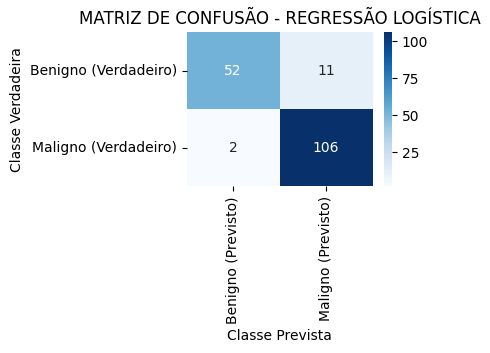

In [ ]:
# MÉTRICAS DE AVALIAÇÃO:
print("ACURÁCIA:", accuracy_score(y_test, y_pred))
print("\nRELATÓRIO DE CLASSIFICAÇÃO:\n", classification_report(y_test, y_pred))

# CALCULAR MATRIZ DE CONFUSÃO
cm = confusion_matrix(y_test, y_pred)

# PLOTAR MATRIZ DE CONFUSÃO
plt.figure(figsize=(3, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno (Previsto)', 'Maligno (Previsto)'],
            yticklabels=['Benigno (Verdadeiro)', 'Maligno (Verdadeiro)'])
plt.ylabel('Classe Verdadeira')
plt.xlabel('Classe Prevista')
plt.title('MATRIZ DE CONFUSÃO - REGRESSÃO LOGÍSTICA')
plt.show()

In [58]:
# COEFICIENTES DO MODELO
coef_df = pd.DataFrame({'Feature': X.columns, 'Coeficiente': model.coef_[0]})
print("\nCOEFICIENTES DO MODELO:")
print(coef_df)


COEFICIENTES DO MODELO:
          Feature  Coeficiente
0     mean radius    -0.864362
1  mean concavity    -2.732895


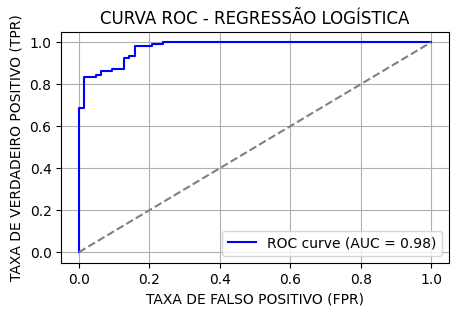

In [63]:
# OBTER AS PROBABILIDADES PREVISTAS PARA A CLASSE MALIGNA (1)
y_prob = model.predict_proba(X_test)[:, 1]

# CALCULAR FPR, TPR E THRESHOLDS PARA CURVA ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# CALCULAR AUC
roc_auc = roc_auc_score(y_test, y_prob)

# PLOTAR CURVA ROC
plt.figure(figsize=(5,3))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('TAXA DE FALSO POSITIVO (FPR)')
plt.ylabel('TAXA DE VERDADEIRO POSITIVO (TPR)')
plt.title('CURVA ROC - REGRESSÃO LOGÍSTICA')
plt.legend()
plt.grid(True)
plt.show()

# 5. CONCLUSÃO:

O modelo de regressão logística desenvolvido neste projeto, utilizando apenas duas variáveis selecionadas por correlação e evitando multicolinearidade, apresentou excelente desempenho preditivo. A acurácia, a matriz de confusão e principalmente o valor AUC de 0.98 na curva ROC mostram que o classificador é altamente eficaz em distinguir casos de câncer de mama benignos e malignos neste conjunto de dados.

Além da performance, o workflow adotado garante robustez estatística, com foco em simplicidade, transparência e interpretabilidade — características fundamentais tanto para aplicações clínicas quanto para projetos de ciência de dados aplicados. Este resultado evidencia que uma seleção criteriosa de variáveis pode ser suficiente para alcançar excelente poder discriminante, mesmo sem modelos excessivamente complexos. 

Como próximos passos, é possível explorar técnicas de regularização, criar gráficos explicativos do impacto das variáveis e ampliar os testes para diferentes subconjuntos de dados, reforçando ainda mais a validade do modelo para aplicações reais.
